# Outcome Choice and Causal Credibility in Crypto Funding Premiums

**Chapter 15: Causal Estimation with ML**
**Docker image**: `ml4t`
**Section Reference**: Section 15.2 on outcome choice, Section 15.3 for the validation
workflow, and Section 15.4 (Table 15.2) for the two-outcome contrast

## Purpose
One treatment, two outcomes, and two very different levels of causal credibility.
The treatment is the premium *state* rather than the funding payment: the perpetual
trading above spot by more than two standard deviations, which creates funding
pressure and an arbitrage incentive. The outcomes are forward returns, a broad market
variable exposed to everything that moves crypto, and forward premium reversion, which
the funding mechanism acts on directly. The same estimator, the same adjustment set and
the same validation battery reach different conclusions about the two.

## Learning Objectives
After completing this notebook, you will be able to:
- LO1: Specify a DAG in DoWhy and read the adjustment set it identifies
- LO2: Explain how the tightness of the treatment-outcome mechanism bounds credibility
- LO3: Judge whether the available controls can plausibly block the backdoor paths a
  given treatment-outcome pair opens
- LO4: Read a partial-R2 sensitivity analysis and the robustness value it reports

## Cross-References
- **Upstream**: crypto premium index and perpetual OHLCV from `data/crypto/download.py`
- **Downstream**: [`04_dml_crypto_regime`](04_dml_crypto_regime.ipynb) applies DML to the
  same data with regime heterogeneity
- **Related**: [`01_library_overview`](01_library_overview.ipynb) for where DoWhy sits
  among the chapter's libraries

## Data Requirements
- Crypto premium index at 8h frequency - loaded via `load_crypto_premium(frequency="8h")`
- Crypto perpetual futures OHLCV at 1h frequency - loaded via `load_crypto_perps(frequency="1h")`

Both are produced by `data/crypto/download.py`.

## Causal Design

| Outcome              | Mechanism                              | Main validation tests                                                              |
|----------------------|----------------------------------------|------------------------------------------------------------------------------------|
| Forward 24h returns  | Indirect sentiment and risk channel    | OOS stability, placebo-date shift, return-scale and reversion-scale negative controls, partial-R2 sensitivity |
| Forward 24h premium  | Direct arbitrage-pressure channel      | OOS stability, placebo-date shift, return-scale and reversion-scale negative controls, partial-R2 sensitivity |

The computed comparison table appears at the end of the notebook.

## Causal Design Contract

| Element                   | Definition                                                                            |
|---------------------------|---------------------------------------------------------------------------------------|
| Unit                      | One BTC 8-hour bar                                                                    |
| Treatment                 | `extreme_high_premium` = `premium_zscore > 2` (binary indicator of premium state)     |
| Outcomes                  | `fwd_return_24h` (3 bars) and `fwd_premium_change` (3 bars)                           |
| Controls                  | `return_24h`, `volatility_24h` (both backward-looking, strictly pre-treatment)        |
| Effect modifiers          | None in this notebook                                                                 |
| Identification assumption | Selection on observables given the specified DAG; no contemporaneous unobserved cause |
| Main failure modes        | Unobserved confounding (sentiment shocks), bad controls, mistimed treatment           |
| Estimand                  | ATE of entering the extreme-high-premium state - not the marginal effect of a one-unit change in premium z-score |

**Prerequisites**: [`01_library_overview`](01_library_overview.ipynb) for library context

## The Crypto Funding Rate Mechanism

In perpetual futures markets:
- **Premium** = (perp price - spot price) / spot price
- **Funding rate** = periodic payment to close the gap
- **High premium** $\rightarrow$ longs pay shorts $\rightarrow$ pressure to close longs

**Two causal questions**:
1. Does an extreme high premium cause future **returns**? This is what a directional
   trader wants to know.
2. Does an extreme high premium cause premium **reversion**? This is what an
   arbitrageur acts on.

The two questions share a treatment and differ in how much of the world sits between
that treatment and the outcome.

## Setup

Three third-party warnings are silenced by category and module. DoWhy compiles regular
expressions and docstrings with unescaped backslashes, which Python reports while
importing the package. pydot, which parses the graph string, calls pyparsing methods that
pyparsing has renamed. The third is a dead branch in DoWhy's `robustness_value_func`:
under its default significance level it compares against `1 / f_critical` where
`f_critical` is zero by construction, so the comparison is against infinity and never
fires. Convergence warnings and every other numerical warning stay visible.

## Timing Protocol

Causal validity here rests entirely on the ordering below: every confounder is
computed from bars that close before the treatment is measured, and every outcome
from bars that open after it.

```
Time:        t-168h         t-24h           t            t+24h
             |               |              |              |
             +-- premium_ma -+              |              |
             +-- premium_std +              |              |
                             +- return_24h -+              |
                             +- volatility_24h -+          |
                                             |              |
                                   premium_zscore (treatment)
                                   extreme_high_premium (treatment: z > 2)
                                             |              |
                                             +- fwd_return_24h --+
                                             +- fwd_premium_change -+

Key: All confounders computed BEFORE treatment decision time.
Outcome is strictly FORWARD-looking from treatment time.
```

In [1]:
"""Causal Inference on Crypto Premiums - demonstrate why outcome choice matters for causal credibility."""

import warnings
from datetime import datetime

import dowhy
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import polars as pl
import statsmodels.api as sm
from dowhy import CausalModel
from IPython.display import Markdown, display
from scipy import stats

from data import load_crypto_perps, load_crypto_premium
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt

# Three third-party warnings, silenced by category and module; see the note above.
warnings.filterwarnings("ignore", category=SyntaxWarning, module=".*dowhy")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pydot")
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message="divide by zero encountered in scalar divide",
    module=".*linear_sensitivity_analyzer",
)

# networkx 3.x compatibility (d_separated moved under d_separation)
if not hasattr(nx.algorithms, "d_separated") and hasattr(
    nx.algorithms.d_separation, "is_d_separator"
):
    nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator

In [2]:
MAX_SYMBOLS = 0
START_DATE = "2019-01-01"
SEED = 42

In [3]:
set_global_seeds(SEED)

print(f"DoWhy version: {dowhy.__version__}")

DoWhy version: 0.14


## Configuration

In [4]:
# Configuration - readers can modify these
N_SAMPLES = 20000
EXTREME_THRESHOLD = 2.0  # Z-score threshold
REFUTATION_SIMULATIONS = 50

# The backdoor adjustment set, declared once. Both DAGs below draw the same two edges into
# the treatment and into their outcome, so both identify the same set, and every estimator
# and diagnostic in the notebook conditions on exactly these two.
CONTROLS = ("return_24h", "volatility_24h")

# Train/test split date (temporal, not random)
TRAIN_END_DATE = "2023-06-30"

rng = np.random.default_rng(SEED)

## 1. Load and Prepare Data

In [5]:
# Load premium index (8h frequency) and OHLCV (1h, resampled to 8h) via the canonical loaders
premium = load_crypto_premium(frequency="8h")
ohlcv_1h = load_crypto_perps(frequency="1h")

print(f"Premium data (8h): {premium.shape}")
print(f"OHLCV data (1h): {ohlcv_1h.shape}")

Premium data (8h): (107839, 6)
OHLCV data (1h): (866484, 7)


In [6]:
# Focus on BTC for clean single-asset analysis
btc_prem = premium.filter(pl.col("symbol") == "BTCUSDT").sort("timestamp")

# Resample 1h OHLCV to 8h to match premium frequency
btc_ohlcv_1h = ohlcv_1h.filter(pl.col("symbol") == "BTCUSDT").sort("timestamp")
btc_ohlcv = (
    btc_ohlcv_1h.group_by_dynamic("timestamp", every="8h")
    .agg(
        pl.col("open").first(),
        pl.col("high").max(),
        pl.col("low").min(),
        pl.col("close").last(),
        pl.col("volume").sum(),
    )
    .sort("timestamp")
)

# Merge premium and OHLCV on 8h timestamps
btc = btc_prem.join(
    btc_ohlcv.select(["timestamp", "close", "volume"]),
    on="timestamp",
    how="inner",
)

print(f"BTC data (8h): {btc.shape}")
print(f"Date range: {btc['timestamp'].min()} to {btc['timestamp'].max()}")

BTC data (8h): (6555, 8)
Date range: 2020-01-01 00:00:00+00:00 to 2025-12-31 16:00:00+00:00


### Feature Engineering

Every confounder is built from bars that close before the treatment is measured, and the
`shift(1)` on each rolling window is what enforces it. At the 8-hour cadence, 3 bars span
24 hours and 21 bars span 7 days.

The cell also builds two negative-control outcomes over 24-hour windows that end 48 hours
*before* the treatment, so the treatment cannot reach them. There is one on each headline
outcome's scale, a return and a premium change, so each estimate has a control measured in
its own units.

In [7]:
# Step 1: Base features
btc = btc.with_columns(
    pl.col("premium_index_close").alias("premium"),
    pl.col("close").pct_change().alias("return_8h"),
)

# Step 2: Rolling features (backward-looking only)
# At 8h frequency: 21 bars = 7 days, 3 bars = 24h
btc = btc.with_columns(
    # Rolling stats: 7-day window (21 bars at 8h), shifted by 1 bar
    pl.col("premium").shift(1).rolling_mean(window_size=21).alias("premium_ma"),
    pl.col("premium").shift(1).rolling_std(window_size=21).alias("premium_std"),
    # 24h return and volatility: 3 bars at 8h, shifted by 1 bar
    pl.col("return_8h").shift(1).rolling_sum(window_size=3).alias("return_24h"),
    pl.col("return_8h").shift(1).rolling_std(window_size=3).alias("volatility_24h"),
)

# Step 3: Treatment (measured at time t) and outcomes (forward-looking)
btc = btc.with_columns(
    # Premium z-score at time t (treatment)
    ((pl.col("premium") - pl.col("premium_ma")) / pl.col("premium_std")).alias("premium_zscore"),
    # Forward premium change: t to t+24h = 3 bars (OUTCOME 2: reversion)
    (pl.col("premium").shift(-3) - pl.col("premium")).alias("fwd_premium_change"),
    # Forward return: t to t+24h = 3 bars (OUTCOME 1: returns)
    pl.col("close").pct_change(n=3).shift(-3).alias("fwd_return_24h"),
    # Negative controls, one on each outcome's scale
    pl.col("close").pct_change(n=3).shift(6).alias("past_return_48h"),
    (pl.col("premium").shift(6) - pl.col("premium").shift(9)).alias("past_premium_change_48h"),
)

# Step 4: Binary treatment
btc = btc.with_columns(
    (pl.col("premium_zscore") > EXTREME_THRESHOLD).cast(pl.Int32).alias("extreme_high_premium"),
)

# Drop nulls
btc = btc.drop_nulls()

print(f"After feature engineering: {btc.shape}")

After feature engineering: (6531, 20)


## 2. Train/Test Split

We use a temporal split consistent with the pre-treatment timing discipline
discussed in Section 15.2.

Because the outcome is 24-hour forward (3 bars at 8h frequency), training
rows within the last `HORIZON_BARS` of the cutoff would realize outcomes
*inside* the test window. That boundary band is purged, so every training outcome is
fully observed before the test period begins. The split boundary is cast to the data's
own timestamp dtype, which avoids a resolution or timezone mismatch.

In [8]:
HORIZON_BARS = 3  # 24h forward outcome at 8h frequency
PURGE_HOURS = 8 * HORIZON_BARS

train_end = datetime.fromisoformat(TRAIN_END_DATE)
train_end_lit = pl.lit(train_end).cast(btc["timestamp"].dtype)
purge_boundary_lit = pl.lit(train_end - pd.Timedelta(hours=PURGE_HOURS)).cast(
    btc["timestamp"].dtype
)

# Temporal split with horizon purge: training rows must have outcomes that
# realize before the test period starts.
train_data = btc.filter(pl.col("timestamp") <= purge_boundary_lit)
test_data = btc.filter(pl.col("timestamp") > train_end_lit)

# Subsample to N_SAMPLES using MOST RECENT observations (not random)
if len(test_data) > N_SAMPLES:
    test_data = test_data.tail(N_SAMPLES)

train_sample_size = min(len(train_data), N_SAMPLES)
train_data = train_data.tail(train_sample_size)

# Convert to pandas for DoWhy
df_train = train_data.to_pandas()
df_test = test_data.to_pandas()

print(
    f"Train: {len(df_train):,} obs (up to {TRAIN_END_DATE}), "
    f"extreme rate: {df_train['extreme_high_premium'].mean():.1%}"
)
print(
    f"Test:  {len(df_test):,} obs (after {TRAIN_END_DATE}), "
    f"extreme rate: {df_test['extreme_high_premium'].mean():.1%}"
)

Train: 3,784 obs (up to 2023-06-30), extreme rate: 4.8%
Test:  2,744 obs (after 2023-06-30), extreme rate: 5.3%


## 3. Descriptive Statistics: Is There Anything to Explain?

Before any causal question, the association has to exist. An AR(1) regression of the
forward premium change on the premium z-score, fitted on the training set, measures it,
and the two reversion rates below count how often an extreme reading in either direction
is followed by a move back toward the mean within 24 hours.

In [9]:
slope, intercept, r, p, se = stats.linregress(
    df_train["premium_zscore"], df_train["fwd_premium_change"]
)

print("AR(1): premium_zscore -> fwd_premium_change (train)")
print(f"  Slope: {slope:.6f}, t={slope / se:.1f}, p={p:.2e}, R2={r**2:.3f}")

# Reversion rates
extreme_high = df_train["premium_zscore"] > EXTREME_THRESHOLD
extreme_low = df_train["premium_zscore"] < -EXTREME_THRESHOLD

if extreme_high.sum() > 0:
    high_reverts = (df_train.loc[extreme_high, "fwd_premium_change"] < 0).mean()
    print(f"  Extreme HIGH -> drops in 24h: {high_reverts:.1%}")

if extreme_low.sum() > 0:
    low_reverts = (df_train.loc[extreme_low, "fwd_premium_change"] > 0).mean()
    print(f"  Extreme LOW  -> rises in 24h: {low_reverts:.1%}")

AR(1): premium_zscore -> fwd_premium_change (train)
  Slope: -0.000160, t=-35.6, p=9.10e-240, R2=0.251
  Extreme HIGH -> drops in 24h: 86.3%
  Extreme LOW  -> rises in 24h: 90.6%


The association is there, and it is not subtle. Everything that follows is about whether
it reflects an effect of the premium state on what comes next, or the same forces showing
up in both, and about how far the answer depends on which outcome is asked about.

## 4. Causal Graph Specification

We specify a DAG encoding our domain knowledge. The treatment
`extreme_high_premium` is a directional indicator: premium z-score
above the threshold. Using a directional treatment avoids the
cancellation that arises from combining extreme high and low premiums.

```
    return_24h ---------> extreme_high_premium
         |                        |
         v                        v
    volatility_24h -----> OUTCOME
```

Both confounders (recent returns and volatility) affect the treatment
and the outcome, creating backdoor paths that the adjustment set must
block. The sensitivity analysis below quantifies how much *additional*
unobserved confounding would change our conclusions.

In [10]:
# DAG for returns outcome (more confounded)
graph_returns = """
digraph {
    return_24h -> extreme_high_premium;
    return_24h -> fwd_return_24h;

    volatility_24h -> extreme_high_premium;
    volatility_24h -> fwd_return_24h;

    extreme_high_premium -> fwd_return_24h;
}
"""

# DAG for reversion outcome (tighter mechanism)
graph_reversion = """
digraph {
    return_24h -> extreme_high_premium;
    return_24h -> fwd_premium_change;

    volatility_24h -> extreme_high_premium;
    volatility_24h -> fwd_premium_change;

    extreme_high_premium -> fwd_premium_change;
}
"""

There is deliberately no DAG for the two negative-control outcomes. Both precede the
treatment, so a correct graph omits any edge from `extreme_high_premium` into them, and
DoWhy's backdoor identification then returns zero by construction: the graph rules the
path out and reports nothing about the data. Section 9 measures the residual association
directly instead, with an OLS regression on the same adjustment set, which is a placebo
diagnostic rather than an identifiable causal effect.

### Identifying the Adjustment Set

DoWhy's `identify_effect` applies the backdoor criterion to our DAG and
determines which variables must be conditioned on to block confounding paths.
The estimand below shows the identified adjustment set.

In [11]:
# Use the returns graph to demonstrate identification
model_demo = CausalModel(
    data=df_train,
    treatment="extreme_high_premium",
    outcome="fwd_return_24h",
    graph=graph_returns,
)
estimand_demo = model_demo.identify_effect(proceed_when_unidentifiable=True)
print(estimand_demo)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
           d                                                        
───────────────────────(E[fwd_return_24h|return_24h,volatility_24h])
d[extreme_high_premium]                                             
Estimand assumption 1, Unconfoundedness: If U→{extreme_high_premium} and U→fwd_return_24h then P(fwd_return_24h|extreme_high_premium,return_24h,volatility_24h,U) = P(fwd_return_24h|extreme_high_premium,return_24h,volatility_24h)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
           d                                                        
───────────────────────(E[fwd_return_24h|return_24h,volatility_24h])
d[extreme_high_premium]                                             
Estimand assumption 1, Unconfoundedness: I

The backdoor adjustment set consists of `{return_24h, volatility_24h}` --
these are the observed confounders that lie on non-causal paths between
treatment and outcome. By conditioning on them, we block spurious
associations while leaving the causal path
`extreme_high_premium` $\rightarrow$ `outcome` open.
Both graphs share the same adjustment set because the confounding structure
is identical; only the outcome variable differs.

## 5. Causal Analysis Helper Functions

We split the analysis pipeline into three reusable stages:
estimation, refutation, and sensitivity analysis.

### Fit and Estimate

Build a `CausalModel`, identify the estimand via the backdoor criterion,
and estimate the average treatment effect (ATE) using linear regression.

In [12]:
def fit_and_estimate(df, outcome_col, graph):
    """Identify and estimate causal effect using DoWhy backdoor criterion.

    Returns (estimate, estimand, model) tuple.
    """
    model = CausalModel(
        data=df,
        treatment="extreme_high_premium",
        outcome=outcome_col,
        graph=graph,
    )
    estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        estimand,
        method_name="backdoor.linear_regression",
    )
    return estimate, estimand, model

### HAC Standard Errors

DoWhy's `linear_regression` estimator reports iid standard errors. For
8-hour crypto series the residuals are autocorrelated by construction -
rolling-window confounders and overlapping forward outcomes both carry
persistence. We complement each DoWhy estimate with an OLS regression
that uses the same adjustment set and Newey-West HAC standard errors,
keeping the pedagogy of DoWhy while giving readers inference that matches
the data structure.

In [13]:
def estimate_backdoor_ols_hac(
    df,
    outcome_col,
    treatment_col="extreme_high_premium",
    controls=CONTROLS,
    maxlags=HORIZON_BARS,
):
    """Adjusted treatment effect with HAC (Newey-West) standard errors.

    The lag count defaults to `HORIZON_BARS`, the number of 8-hour bars the forward outcome
    spans, because that is the window over which consecutive outcomes overlap and their
    residuals are correlated by construction. The point estimate matches
    `backdoor.linear_regression` up to numerical precision; the standard error does not.
    """
    cols = [treatment_col, *controls]
    X = sm.add_constant(df[cols])
    y = df[outcome_col]
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return {
        "effect": float(model.params[treatment_col]),
        "se_hac": float(model.bse[treatment_col]),
        "t_hac": float(model.tvalues[treatment_col]),
        "p_hac": float(model.pvalues[treatment_col]),
    }

### Refutation Tests

Two of DoWhy's refuters run on each estimate. The **placebo-treatment** refuter permutes
the treatment column, which destroys any real treatment-outcome link while leaving the
marginal distributions intact: an estimate that stays large under permutation is being
produced by something other than the treatment. The **random-common-cause** refuter adds
an independent draw to the adjustment set, which cannot confound anything: an estimate
that moves is unstable to the adjustment set itself.

Both are reported as ratios to the original estimate rather than as pass or fail, because
what counts as small depends on the estimate's own standard error, which the ratio does
not carry.

In [14]:
def run_refutations(model, estimand, estimate, n_sims=20):
    """Run the placebo-treatment and random-common-cause refuters.

    Returns a dict mapping test name to a ratio against the original estimate: the placebo
    effect's magnitude, and the shift the random common cause induces. Both are unitless,
    so they compare across the two outcomes.
    """
    denominator = max(abs(estimate.value), 1e-8)

    refute_placebo = model.refute_estimate(
        estimand,
        estimate,
        method_name="placebo_treatment_refuter",
        placebo_type="permute",
        num_simulations=n_sims,
    )
    refute_random = model.refute_estimate(
        estimand,
        estimate,
        method_name="random_common_cause",
        num_simulations=n_sims,
    )
    return {
        "Placebo treatment |effect| / |original|": abs(refute_placebo.new_effect) / denominator,
        "Random common cause |shift| / |original|": abs(refute_random.new_effect - estimate.value)
        / denominator,
    }

### Sensitivity Analysis

Section 15.3 poses the sensitivity question as *how strong would an omitted confounder
have to be to overturn the result*. For a linear backdoor estimate that question has a
closed-form answer: the **robustness value** is the partial $R^2$ an unobserved confounder
would need with both the treatment and the outcome, after the observed controls, to drive
the estimate to zero (Cinelli and Hazlett, 2020). DoWhy computes it through
`simulation_method="linear-partial-R2"`.

The partial $R^2$ parameterization is what makes the two outcomes comparable. It is a
share of residual variance, so it does not inherit the scale of the outcome, and a
forward return measured in percent and a premium change measured in index points land on
the same axis. Passing the observed controls as `benchmark_common_causes` additionally
expresses a hypothetical confounder as a multiple of the ones already in the model.

In [15]:
def run_sensitivity(model, estimand, estimate, benchmark_covariates):
    """Partial-R2 sensitivity analysis for a linear backdoor estimate.

    Returns DoWhy's LinearSensitivityAnalyzer. Its `stats` carry the robustness value, the
    robustness value at the 5% significance level, and the t-statistic of the unadjusted
    estimate; `compute_bias_adjusted(r2tu, r2yu)` returns the estimate an omitted confounder
    of that strength would leave.
    """
    return model.refute_estimate(
        estimand,
        estimate,
        method_name="add_unobserved_common_cause",
        simulation_method="linear-partial-R2",
        benchmark_common_causes=list(benchmark_covariates),
        effect_fraction_on_treatment=[1],
        effect_fraction_on_outcome=[1],
        # DoWhy draws its own contour plot and calls plt.show() on it unless this is
        # off. The figure below covers the same ground on one axis for both outcomes.
        plot_estimate=False,
    )

## 6. Analysis A: Returns as Outcome

We first test whether extreme high premium *causes* forward BTC returns.
The mechanism here is indirect: high premium reflects bullish sentiment,
which may also drive returns through other channels.

In [16]:
n_sims = REFUTATION_SIMULATIONS

# Estimate on train
est_ret_train, estd_ret_train, model_ret_train = fit_and_estimate(
    df_train, "fwd_return_24h", graph_returns
)
# Estimate on test (out-of-sample)
est_ret_test, _, _ = fit_and_estimate(df_test, "fwd_return_24h", graph_returns)

ate_diff_ret = abs(est_ret_train.value - est_ret_test.value) / max(abs(est_ret_train.value), 1e-6)
stable_ret = ate_diff_ret < 0.5

print(f"ATE (train): {est_ret_train.value:.6f}")
print(f"ATE (test):  {est_ret_test.value:.6f}")
print(f"Train/test difference: {ate_diff_ret:.1%} {'(stable)' if stable_ret else '(unstable)'}")

ATE (train): -0.002919
ATE (test):  -0.000434
Train/test difference: 85.1% (unstable)


In [17]:
# HAC-corrected inference on the same adjustment set
hac_ret = estimate_backdoor_ols_hac(df_train, "fwd_return_24h")
print(
    f"OLS+HAC effect: {hac_ret['effect']:.6f}, "
    f"SE: {hac_ret['se_hac']:.6f}, "
    f"t: {hac_ret['t_hac']:.2f}, "
    f"p: {hac_ret['p_hac']:.3f}"
)

OLS+HAC effect: -0.002919, SE: 0.002920, t: -1.00, p: 0.317


DoWhy's refuters draw from numpy's legacy global stream, so it is reseeded before each
refutation block. Without that, the second outcome's draws would depend on how many the
first one consumed.

In [18]:
np.random.seed(SEED)
refut_ret = run_refutations(model_ret_train, estd_ret_train, est_ret_train, n_sims)
for test_name, ratio in refut_ret.items():
    print(f"  {test_name}: {ratio:.3f}")

  Placebo treatment |effect| / |original|: 0.110
  Random common cause |shift| / |original|: 0.002


In [19]:
sens_ret = run_sensitivity(model_ret_train, estd_ret_train, est_ret_train, CONTROLS)
rv_ret = float(sens_ret.stats["robustness_value"])
print(f"Unadjusted t-statistic (iid): {sens_ret.stats['t_statistic']:.2f}")
print(f"Robustness value: {rv_ret:.4f}")

Unadjusted t-statistic (iid): -1.03
Robustness value: 0.0166


The robustness value answers a question the reader can weigh against what they know about
crypto markets: an omitted confounder explaining that share of the residual variance of
both the treatment and the outcome would move the estimate to zero.

It is a statement about the fit's algebra rather than about its sampling uncertainty. The
robustness value is a function of the partial $R^2$ of the treatment with the outcome,
which the OLS fit fixes through the identity $t^2 / \mathit{df} = R^2 / (1 - R^2)$.
Replacing the iid standard error with a HAC one changes what the estimate claims about its
own precision; it changes neither the fitted coefficient nor the residual variances the
omitted-variable bias formula operates on, so it leaves the robustness value where it is.

That split is why DoWhy's robustness value *at a significance level* is omitted here.
That one asks how much confounding would make the estimate statistically indistinguishable
from zero, which is a question about standard errors, and the OLS+HAC regression above
shows the iid standard error is not the right one for overlapping 24-hour outcomes.

## 7. Analysis B: Premium Reversion as Outcome

Now we test whether extreme high premium causes premium *reversion*. The
mechanism here is direct: high premium triggers arbitrage trades
(sell perp, buy spot) that mechanically push the premium back toward zero.

In [20]:
# Estimate on train
est_rev_train, estd_rev_train, model_rev_train = fit_and_estimate(
    df_train, "fwd_premium_change", graph_reversion
)
# Estimate on test (out-of-sample)
est_rev_test, _, _ = fit_and_estimate(df_test, "fwd_premium_change", graph_reversion)

ate_diff_rev = abs(est_rev_train.value - est_rev_test.value) / max(abs(est_rev_train.value), 1e-6)
stable_rev = ate_diff_rev < 0.5

print(f"ATE (train): {est_rev_train.value:.6f}")
print(f"ATE (test):  {est_rev_test.value:.6f}")
print(f"Train/test difference: {ate_diff_rev:.1%} {'(stable)' if stable_rev else '(unstable)'}")

ATE (train): -0.000595
ATE (test):  -0.000290
Train/test difference: 51.3% (unstable)


In [21]:
# HAC-corrected inference on the same adjustment set
hac_rev = estimate_backdoor_ols_hac(df_train, "fwd_premium_change")
print(
    f"OLS+HAC effect: {hac_rev['effect']:.6f}, "
    f"SE: {hac_rev['se_hac']:.6f}, "
    f"t: {hac_rev['t_hac']:.2f}, "
    f"p: {hac_rev['p_hac']:.3f}"
)

OLS+HAC effect: -0.000595, SE: 0.000049, t: -12.23, p: 0.000


In [22]:
np.random.seed(SEED)
refut_rev = run_refutations(model_rev_train, estd_rev_train, est_rev_train, n_sims)
for test_name, ratio in refut_rev.items():
    print(f"  {test_name}: {ratio:.3f}")

  Placebo treatment |effect| / |original|: 0.009
  Random common cause |shift| / |original|: 0.000


In [23]:
sens_rev = run_sensitivity(model_rev_train, estd_rev_train, est_rev_train, CONTROLS)
rv_rev = float(sens_rev.stats["robustness_value"])
print(f"Unadjusted t-statistic (iid): {sens_rev.stats['t_statistic']:.2f}")
print(f"Robustness value: {rv_rev:.4f}")

Unadjusted t-statistic (iid): -17.67
Robustness value: 0.2491


A larger robustness value does not make the reversion claim safe. Liquidity, funding
congestion, exchange credit risk and market-wide leverage can all move both the
extreme-premium state and the speed at which it decays, and none of them is in the
adjustment set. What the robustness value bounds is how weak such a confounder could be
and still overturn the estimate, which is a floor on the argument rather than a defence
of it. The reversion outcome is also mechanically close to the treatment, since both are
built from the same premium series, so part of the measured decay is ordinary mean
reversion after an extreme reading.

## 8. Side-by-Side Comparison

In [24]:
comparison = pd.DataFrame(
    {
        "Metric": [
            "ATE (train)",
            "ATE (test)",
            "OOS drift",
            "Robustness value",
        ],
        "Returns": [
            f"{est_ret_train.value:.6f}",
            f"{est_ret_test.value:.6f}",
            f"{ate_diff_ret:.1%}",
            f"{rv_ret:.4f}",
        ],
        "Reversion": [
            f"{est_rev_train.value:.6f}",
            f"{est_rev_test.value:.6f}",
            f"{ate_diff_rev:.1%}",
            f"{rv_rev:.4f}",
        ],
    }
).set_index("Metric")

display(comparison)

,Returns,Reversion
Metric,,
ATE (train),-0.002919,-0.000595
ATE (test),-0.000434,-0.000290
OOS drift,85.1%,51.3%
Robustness value,0.0166,0.2491


### How Fast Each Estimate Decays Under Omitted Confounding

Each curve traces what an omitted confounder of a given strength would leave of the
estimate, as a fraction of the estimate the notebook actually reports. Both start at one,
because a confounder of zero strength changes nothing, and each crosses zero at its own
robustness value. Plotting the fraction rather than the level is what puts the two
outcomes on one axis: the ATEs themselves differ by a factor of five and are measured in
different units.

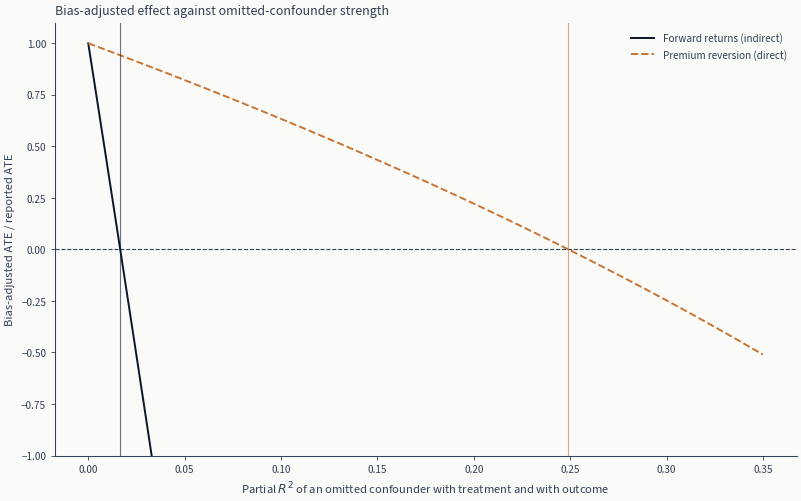

In [25]:
confounder_grid = np.linspace(0.0, 0.35, 71)


def bias_adjusted_fraction(analyzer, unadjusted_estimate):
    """Bias-adjusted estimate as a fraction of the unadjusted one, along r2tu = r2yu."""
    adjusted = [
        float(analyzer.compute_bias_adjusted(strength, strength)["bias_adjusted_estimate"])
        for strength in confounder_grid
    ]
    return np.asarray(adjusted) / unadjusted_estimate


ret_fraction = bias_adjusted_fraction(sens_ret, est_ret_train.value)
rev_fraction = bias_adjusted_fraction(sens_rev, est_rev_train.value)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(confounder_grid, ret_fraction, color=COLORS["blue"], label="Forward returns (indirect)")
ax.plot(
    confounder_grid,
    rev_fraction,
    color=COLORS["copper"],
    linestyle="--",
    label="Premium reversion (direct)",
)
ax.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax.axvline(rv_ret, color=COLORS["blue"], linewidth=0.8, alpha=0.6)
ax.axvline(rv_rev, color=COLORS["copper"], linewidth=0.8, alpha=0.6)
ax.set_ylim(-1.0, 1.1)
ax.set_xlabel("Partial $R^2$ of an omitted confounder with treatment and with outcome")
ax.set_ylabel("Bias-adjusted ATE / reported ATE")
ax.set_title("Bias-adjusted effect against omitted-confounder strength")
ax.legend()

show_with_alt(
    fig,
    "Line chart of the bias-adjusted average treatment effect as a fraction of the "
    "reported estimate, against the partial R-squared an omitted confounder would have "
    "with both the treatment and the outcome. Both curves start at one on the left. The "
    "forward-returns curve falls steeply and crosses zero very close to the left edge, "
    "continuing well below it. The premium-reversion curve declines gradually and crosses "
    "zero near the right of the range. A vertical line marks each crossing point.",
)

## 9. Additional Validation: Placebo Date and Negative Control

Section 15.3 describes two validation tests beyond the sensitivity analysis above. A
**placebo-date test** shifts the treatment assignment by several days, and a credible
effect should vanish once the treatment lands at the wrong time. A **negative-control
outcome** is a pre-treatment variable the treatment cannot cause, so any association the
adjustment leaves there is confounding or leakage rather than an effect.

### Placebo-Date Test

We shift the treatment (`extreme_high_premium`) forward by 21 bars
(7 days at 8h frequency). At each row, the treatment value now comes
from a week earlier -- well outside the 24h mechanism window. If the
original effect is causal, the placebo effect should be near zero.

In [26]:
shift_periods = 21  # 7 days at 8h frequency

# Shift treatment variable and re-estimate for both outcomes
df_placebo = df_train.copy()
df_placebo["extreme_high_premium"] = df_placebo["extreme_high_premium"].shift(shift_periods)
df_placebo = df_placebo.dropna()

est_placebo_rev, _, _ = fit_and_estimate(df_placebo, "fwd_premium_change", graph_reversion)
est_placebo_ret, _, _ = fit_and_estimate(df_placebo, "fwd_return_24h", graph_returns)

placebo_df = pd.DataFrame(
    {
        "Outcome": ["Forward Returns", "Premium Reversion"],
        "Original ATE": [
            f"{est_ret_train.value:.6f}",
            f"{est_rev_train.value:.6f}",
        ],
        "Placebo ATE (7d shift)": [
            f"{est_placebo_ret.value:.6f}",
            f"{est_placebo_rev.value:.6f}",
        ],
        "Ratio |placebo/original|": [
            f"{abs(est_placebo_ret.value) / max(abs(est_ret_train.value), 1e-8):.1%}",
            f"{abs(est_placebo_rev.value) / max(abs(est_rev_train.value), 1e-8):.1%}",
        ],
    }
).set_index("Outcome")

display(placebo_df)

,Original ATE,Placebo ATE (7d shift),Ratio |placebo/original|
Outcome,,,
Forward Returns,-0.002919,0.000371,12.7%
Premium Reversion,-0.000595,0.000034,5.7%


A credible causal effect shrinks toward zero under the placebo, because a treatment
measured a week early has no mechanism by which to reach the outcome. A placebo ATE that
stays close to the original says the association follows something persistent in the
series rather than the treatment arriving when it did. The ratio is the readable form,
since the two outcomes are on different scales.

### Negative-Control Outcomes

Each headline outcome gets its own same-scale negative control:
`past_return_48h` (24h return ending 48h before treatment) for the
returns ATE, and `past_premium_change_48h` (24h premium change ending
48h before treatment) for the reversion ATE.

Because the negative-control DAGs (correctly) omit any
`extreme_high_premium → past_*` edge, DoWhy's backdoor identification
refuses to attribute a causal effect - the *graph structure itself*
rules the path out, and `fit_and_estimate` returns zero by construction.
That is the right behavior for an identifiability check, but it gives
us no numeric diagnostic of *residual association* in the data.

To recover the diagnostic, we run an OLS regression of each past
outcome on the treatment and confounders, with HAC standard errors. If
the coefficient on treatment is non-trivial, the backdoor adjustment is
not blocking all confounding paths - even though no real causal effect
can exist on a pre-treatment outcome.

In [27]:
neg_ret_assoc = estimate_backdoor_ols_hac(df_train, "past_return_48h")
neg_rev_assoc = estimate_backdoor_ols_hac(df_train, "past_premium_change_48h")

neg_ratio_ret = abs(neg_ret_assoc["effect"]) / max(abs(hac_ret["effect"]), 1e-8)
neg_ratio_rev = abs(neg_rev_assoc["effect"]) / max(abs(hac_rev["effect"]), 1e-8)

print("Returns outcome (negative-control association via OLS+HAC):")
print(
    f"  past_return_48h ~ treatment: {neg_ret_assoc['effect']:.6f} "
    f"(SE {neg_ret_assoc['se_hac']:.6f}, t {neg_ret_assoc['t_hac']:.2f}, "
    f"p {neg_ret_assoc['p_hac']:.3f})"
)
print(f"  Relative to returns OLS+HAC effect: {neg_ratio_ret:.1%}")
print("Reversion outcome (negative-control association via OLS+HAC):")
print(
    f"  past_premium_change_48h ~ treatment: {neg_rev_assoc['effect']:.6f} "
    f"(SE {neg_rev_assoc['se_hac']:.6f}, t {neg_rev_assoc['t_hac']:.2f}, "
    f"p {neg_rev_assoc['p_hac']:.3f})"
)
print(f"  Relative to reversion OLS+HAC effect: {neg_ratio_rev:.1%}")

Returns outcome (negative-control association via OLS+HAC):
  past_return_48h ~ treatment: 0.008668 (SE 0.002392, t 3.62, p 0.000)
  Relative to returns OLS+HAC effect: 297.0%
Reversion outcome (negative-control association via OLS+HAC):
  past_premium_change_48h ~ treatment: 0.000024 (SE 0.000029, t 0.84, p 0.398)
  Relative to reversion OLS+HAC effect: 4.1%


Each residual association should be negligible relative to its
corresponding headline effect. A large ratio on one outcome but not the
other signals that the headline claim on the affected outcome inherits
residual confounding the backdoor adjustment did not block. Treat this
as a placebo diagnostic - not an identifiable causal effect - because
the DAG structurally forbids the path.

## 10. What Separates the Two Outcomes

The estimator, the adjustment set and the sample are identical across the two analyses.
What differs is how much of the market sits between the treatment and the outcome, and
that is what the diagnostics are picking up.

### Forward returns
```
market_sentiment -> { premium, returns }   (backdoor path, unmeasured)
          premium -> returns               (causal path, indirect)
```
Speculative demand, leverage and risk appetite move both the funding premium and
subsequent returns, which is a backdoor path the adjustment set has to block.
`return_24h` and `volatility_24h` proxy for part of it and not for the rest, so the path
stays partly open. The residual association the negative control finds on a pre-treatment
return is the direct evidence of it.

### Premium reversion
```
premium -> funding pressure -> arbitrage -> premium reversion   (causal path, direct)
```
Funding makes the long side of the perpetual expensive while the premium is high, which
creates an incentive to sell the perpetual and buy spot, which compresses the premium.
The path is short enough that the same unmeasured sentiment has less room to act on the
outcome independently of the treatment. It is also short enough to be partly mechanical,
since the treatment and the outcome are built from the same premium series.

## 11. Practical Implications

- **Choose the outcome before choosing the estimator.** The outcome decides which
  backdoor paths exist, and therefore whether the available controls can block them while
  leaving the treatment's own mechanism intact. A broad market outcome opens paths through
  everything the adjustment set omits, and no estimator repairs that.
- **Run the checks that fail for different reasons.** The placebo-date shift catches an
  effect that does not depend on timing, the negative control catches adjustment that
  leaves residual association, out-of-sample drift catches a fit to one period, and the
  robustness value says how weak an unseen confounder could be and still erase the
  estimate. Each is blind to what the others see.
- **Read out-of-sample drift on the estimate's own scale.** A large relative drift on a
  small estimate can sit well inside its standard error, so read the drift beside the HAC
  standard error rather than against a fixed cutoff.

## 12. Results Summary

In [28]:
print(f"Train samples: {len(df_train):,}  |  Test samples: {len(df_test):,}")
print(f"Treatment: extreme high premium (z > {EXTREME_THRESHOLD})\n")
print(
    f"Returns   -- ATE train: {est_ret_train.value:.6f}, test: {est_ret_test.value:.6f}, "
    f"OOS drift: {ate_diff_ret:.1%}, robustness value: {rv_ret:.4f}"
)
print(
    f"Reversion -- ATE train: {est_rev_train.value:.6f}, test: {est_rev_test.value:.6f}, "
    f"OOS drift: {ate_diff_rev:.1%}, robustness value: {rv_rev:.4f}"
)

Train samples: 3,784  |  Test samples: 2,744
Treatment: extreme high premium (z > 2.0)

Returns   -- ATE train: -0.002919, test: -0.000434, OOS drift: 85.1%, robustness value: 0.0166
Reversion -- ATE train: -0.000595, test: -0.000290, OOS drift: 51.3%, robustness value: 0.2491


### Reading the four diagnostics together

No single diagnostic settles the comparison, and they are not independent of one another.
The cell below reports each of the four side by side, computed from the values above.

In [29]:
display(
    Markdown(
        "| Diagnostic | Forward returns | Premium reversion | What a smaller number means |\n"
        "|---|---|---|---|\n"
        f"| Out-of-sample drift | {ate_diff_ret:.1%} | {ate_diff_rev:.1%} | "
        "the estimate reproduces on data it was not fitted on |\n"
        f"| Placebo-date ratio (7d shift) | "
        f"{abs(est_placebo_ret.value) / max(abs(est_ret_train.value), 1e-8):.1%} | "
        f"{abs(est_placebo_rev.value) / max(abs(est_rev_train.value), 1e-8):.1%} | "
        "the effect depends on the treatment landing at the right time |\n"
        f"| Negative control / headline | {neg_ratio_ret:.1%} | {neg_ratio_rev:.1%} | "
        "the adjustment leaves little association with a pre-treatment outcome |\n"
        f"| Robustness value | {rv_ret:.4f} | {rv_rev:.4f} | "
        "*larger* is better here: a weaker confounder suffices to overturn a small one |\n"
    )
)

| Diagnostic | Forward returns | Premium reversion | What a smaller number means |
|---|---|---|---|
| Out-of-sample drift | 85.1% | 51.3% | the estimate reproduces on data it was not fitted on |
| Placebo-date ratio (7d shift) | 12.7% | 5.7% | the effect depends on the treatment landing at the right time |
| Negative control / headline | 297.0% | 4.1% | the adjustment leaves little association with a pre-treatment outcome |
| Robustness value | 0.0166 | 0.2491 | *larger* is better here: a weaker confounder suffices to overturn a small one |


The negative control is the sharpest of the four, because it is the only one the treatment
cannot influence by construction: any association it finds is residual confounding or
leakage, not a small true effect. The robustness value points the same way, but the two
are not measuring the same thing. The robustness value is conditional on the adjustment
being right and asks how strong a further confounder would have to be; the negative
control is evidence that the adjustment is not right. It says nothing about the partial
$R^2$ any such confounder has with the treatment or with the outcome, so it cannot be read
as a measurement of the quantity the robustness value is expressed in.

Out-of-sample drift separates the two outcomes by degree rather than in kind. Both
estimates move substantially between the training and test periods, so neither is stable
in absolute terms, and the reversion claim is the more defensible of two claims that both
rest on a short sample of one asset.

What none of the four establishes is that the reversion effect is causal. They rule out
specific failures: a result that appears at the wrong date, a result that appears on an
outcome the treatment precedes, a result that vanishes out of sample, a result an
arbitrarily weak confounder would erase. The mechanism argument, that funding makes the
long side expensive and creates a real incentive to sell the perpetual and buy spot, is
what the diagnostics are testing against, and it is doing the work.

## Key Takeaways

1. **The outcome is part of the design, not a reporting choice.** Both outcomes here are
   defensible questions. They differ in how many backdoor paths they open, and therefore
   in whether two controls are enough to block them, which is what the diagnostics detect.
2. **A mechanism-near outcome is easier to defend and easier to trivialize.** Premium
   reversion is close enough to the treatment that ordinary mean reversion after an
   extreme reading explains part of it, which is the cost of the tighter mechanism.
3. **Report which checks an estimate passes and which it fails**, along with the strength
   of omitted confounding that would overturn it. A robustness value near zero says the
   estimate is not separable from confounding the data cannot see.
4. **Adjust the standard errors to the dependence in the data.** Overlapping forward
   outcomes at an 8-hour cadence make the iid standard error too small, which is why every
   estimate here is repeated with Newey-West lags at the outcome horizon.
5. **Confounders before treatment, treatment before outcome**, with the training window
   purged by the outcome horizon so no training row realizes inside the test period.